# Faz 8 — Makale Analiz ve Figür Üretimi

Bu notebook iki makale için gerekli tüm analiz ve figürleri üretir.

**Makale 1:** Multi-Class CT Benchmark for Emergency Abdominal Pathology Detection  
**Makale 2:** WeightedRandomSampler + Per-Class Threshold Optimization for Imbalanced Abdominal Classification

### Çıktılar
Tüm figürler ve tablolar `paper_output/` klasörüne kaydedilir:
- `paper_output/figures/` — PNG + PDF (300 DPI)
- `paper_output/tables/`  — CSV + LaTeX

In [30]:
!pip install statsmodels

In [31]:
# ── Ortam algılama ──────────────────────────────────────────────────────────
import os, sys
from pathlib import Path

IS_COLAB  = 'google.colab' in sys.modules
IS_KAGGLE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None
IS_LOCAL  = not IS_COLAB and not IS_KAGGLE

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/abdomen')
    DATA_DIR     = Path('/content/drive/MyDrive/abdomenDataSet')
elif IS_KAGGLE:
    PROJECT_ROOT = Path('/kaggle/working/abdomen')
    DATA_DIR     = Path('/kaggle/input/abdomen-dataset')
else:  # LOCAL
    import platform
    if platform.system() == 'Windows':
        PROJECT_ROOT = Path(r'D:/makale-pdf/Proje/abdomen')
        DATA_DIR     = Path(r'D:/makale-pdf/Proje/abdomenDataSet')
    else:  # macOS / Linux
        PROJECT_ROOT = Path('/Users/ramazanpolat/Desktop/datasets/abdomen')
        DATA_DIR     = Path('/Users/ramazanpolat/Desktop/datasets/abdomenDataSet')

WORK_DIR    = PROJECT_ROOT if IS_LOCAL else Path('/content' if IS_COLAB else '/kaggle/working')
OUT_DIR     = WORK_DIR / 'outputs'
SPLIT_DIR   = OUT_DIR / 'splits'
PAPER_DIR   = WORK_DIR / 'paper_output'
FIG_DIR     = PAPER_DIR / 'figures'
TABLE_DIR   = PAPER_DIR / 'tables'
RESULTS_DIR = OUT_DIR / 'results'   # JSON sonuç dosyaları burada bekleniyor

for d in [FIG_DIR, TABLE_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
print(f'Ortam: {"LOCAL" if IS_LOCAL else "COLAB" if IS_COLAB else "KAGGLE"}')
print(f'PAPER_DIR: {PAPER_DIR}')

Ortam: LOCAL
PAPER_DIR: /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output


In [32]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_style('whitegrid')

SUPER_CLASSES = [
    'acute_cholecystitis',
    'kidney_ureter_stone',
    'acute_pancreatitis',
    'aortic_aneurysm_dissection',
    'acute_appendicitis',
    'acute_diverticulitis',
]
CLASS_ABBR = ['Chol.', 'Kidney', 'Panc.', 'Aorta', 'App.', 'Diver.']
CLASS_COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
MODEL_COLORS = {'YOLO':'#4C72B0', 'SwinTransformer':'#DD8452',
                'nnUNet':'#55A868', 'MedNeXt':'#C44E52'}

MODELS = ['YOLO', 'SwinTransformer', 'nnUNet', 'MedNeXt']
print('Import OK')

Import OK


## 1. Sonuç Dosyalarını Yükleme

Her model `outputs/results/<model>_results.json` dosyasına sonuçlarını kaydeder.
Eksik modeller için dummy veriler kullanılır (gerçek sonuçlar çalıştırıldıktan sonra otomatik güncellenir).

In [33]:
def load_json(path):
    if Path(path).exists():
        with open(path) as f:
            return json.load(f)
    return None

def make_dummy_results(model_name, seed=42):
    """Gerçek sonuç yokken placeholder üretir — figures şeklini göstermek için."""
    rng = np.random.RandomState(seed)
    base = {'YOLO': 0.72, 'SwinTransformer': 0.68, 'nnUNet': 0.74, 'MedNeXt': 0.76}
    b = base.get(model_name, 0.70)
    per_class = {c: round(float(rng.uniform(b-0.12, b+0.10)), 4) for c in SUPER_CLASSES}
    return {
        'model': model_name,
        'top5_mean_f1': round(b + float(rng.uniform(-0.02, 0.02)), 4),
        'per_class_f1': per_class,
        'per_class_precision': {c: round(float(rng.uniform(b-0.10, b+0.12)), 4) for c in SUPER_CLASSES},
        'per_class_recall':    {c: round(float(rng.uniform(b-0.10, b+0.12)), 4) for c in SUPER_CLASSES},
        'training_history': {
            'epoch': list(range(1, 51)),
            'train_loss': [round(float(2.5 * np.exp(-0.08*e) + rng.uniform(0,0.05)), 4) for e in range(50)],
            'val_loss':   [round(float(2.8 * np.exp(-0.07*e) + rng.uniform(0,0.08)), 4) for e in range(50)],
            'val_f1':     [round(float(b*(1-np.exp(-0.1*e)) + rng.uniform(0,0.02)), 4) for e in range(50)],
        },
        'is_dummy': True
    }

results = {}
for model in MODELS:
    path = RESULTS_DIR / f'{model.lower()}_results.json'
    data = load_json(path)
    if data is None:
        print(f'[UYARI] {path.name} bulunamadı → dummy veri kullanılıyor')
        data = make_dummy_results(model)
    else:
        print(f'[OK] {path.name} yüklendi')
    results[model] = data

# Ablasyon sonuçları
ablation_path = RESULTS_DIR / 'ablation_results.json'
ablation_data = load_json(ablation_path)
if ablation_data is None:
    print('[UYARI] ablation_results.json bulunamadı → dummy veri kullanılıyor')
    ablation_data = {
        'configs': [
            {'name': 'Baseline (BCE)',                     'top5_mean_f1': 0.621, 'per_class_f1': {c: round(0.58+i*0.01,3) for i,c in enumerate(SUPER_CLASSES)}},
            {'name': 'FocalBCE',                           'top5_mean_f1': 0.648, 'per_class_f1': {c: round(0.61+i*0.01,3) for i,c in enumerate(SUPER_CLASSES)}},
            {'name': 'FocalBCE + WeightedSampler',        'top5_mean_f1': 0.683, 'per_class_f1': {c: round(0.64+i*0.01,3) for i,c in enumerate(SUPER_CLASSES)}},
            {'name': 'FocalBCE + Sampler + ThreshTuning', 'top5_mean_f1': 0.712, 'per_class_f1': {c: round(0.67+i*0.01,3) for i,c in enumerate(SUPER_CLASSES)}},
        ],
        'is_dummy': True
    }

# Backbone ablasyon sonuçları
backbone_path = RESULTS_DIR / 'backbone_ablation_results.json'
backbone_data = load_json(backbone_path)
if backbone_data is None:
    print('[UYARI] backbone_ablation_results.json bulunamadı → dummy veri kullanılıyor')
    backbones = ['swin_base', 'convnext_base', 'convnextv2_base', 'vit_base_16', 'dinov2_base', 'eva02_base']
    backbone_data = {
        'results': [
            {'backbone': b, 'top5_mean_f1': round(0.65 + i*0.015, 4),
             'per_class_f1': {c: round(0.62+i*0.01, 4) for c in SUPER_CLASSES}}
            for i, b in enumerate(backbones)
        ],
        'is_dummy': True
    }

print('\nSonuç yükleme tamamlandı.')

[UYARI] yolo_results.json bulunamadı → dummy veri kullanılıyor
[UYARI] swintransformer_results.json bulunamadı → dummy veri kullanılıyor
[UYARI] nnunet_results.json bulunamadı → dummy veri kullanılıyor
[UYARI] mednext_results.json bulunamadı → dummy veri kullanılıyor
[UYARI] ablation_results.json bulunamadı → dummy veri kullanılıyor
[UYARI] backbone_ablation_results.json bulunamadı → dummy veri kullanılıyor

Sonuç yükleme tamamlandı.


In [34]:
# Splits CSV'den veri istatistiklerini yükle
manifest_csv = SPLIT_DIR / 'manifest.csv'
splits_csv   = SPLIT_DIR / 'splits.csv'

df_manifest = pd.read_csv(manifest_csv) if manifest_csv.exists() else None
df_splits   = pd.read_csv(splits_csv)   if splits_csv.exists()   else None

if df_manifest is not None:
    print(f'Manifest: {len(df_manifest)} satır, kolonlar: {list(df_manifest.columns)}')
else:
    print('[UYARI] manifest.csv bulunamadı — Fig1 için dummy istatistikler kullanılacak')

if df_splits is not None:
    print(f'Splits:   {len(df_splits)} satır')

Manifest: 39268 satır, kolonlar: ['case', 'image_id', 'source', 'dicom_path', 'super_labels', 'bboxes', 'anatomical_boundary', 'n_bbox_anns', 'n_boundary_anns']
Splits:   725 satır


## Fig 1 — Dataset İstatistikleri

Train sayıları: {'Chol.': 151, 'Kidney': 168, 'Panc.': 136, 'Aorta': 136, 'App.': 56, 'Diver.': 14}
Val sayıları  : {'Chol.': 36, 'Kidney': 40, 'Panc.': 33, 'Aorta': 34, 'App.': 15, 'Diver.': 4}
Toplam — Train: 661, Val: 162


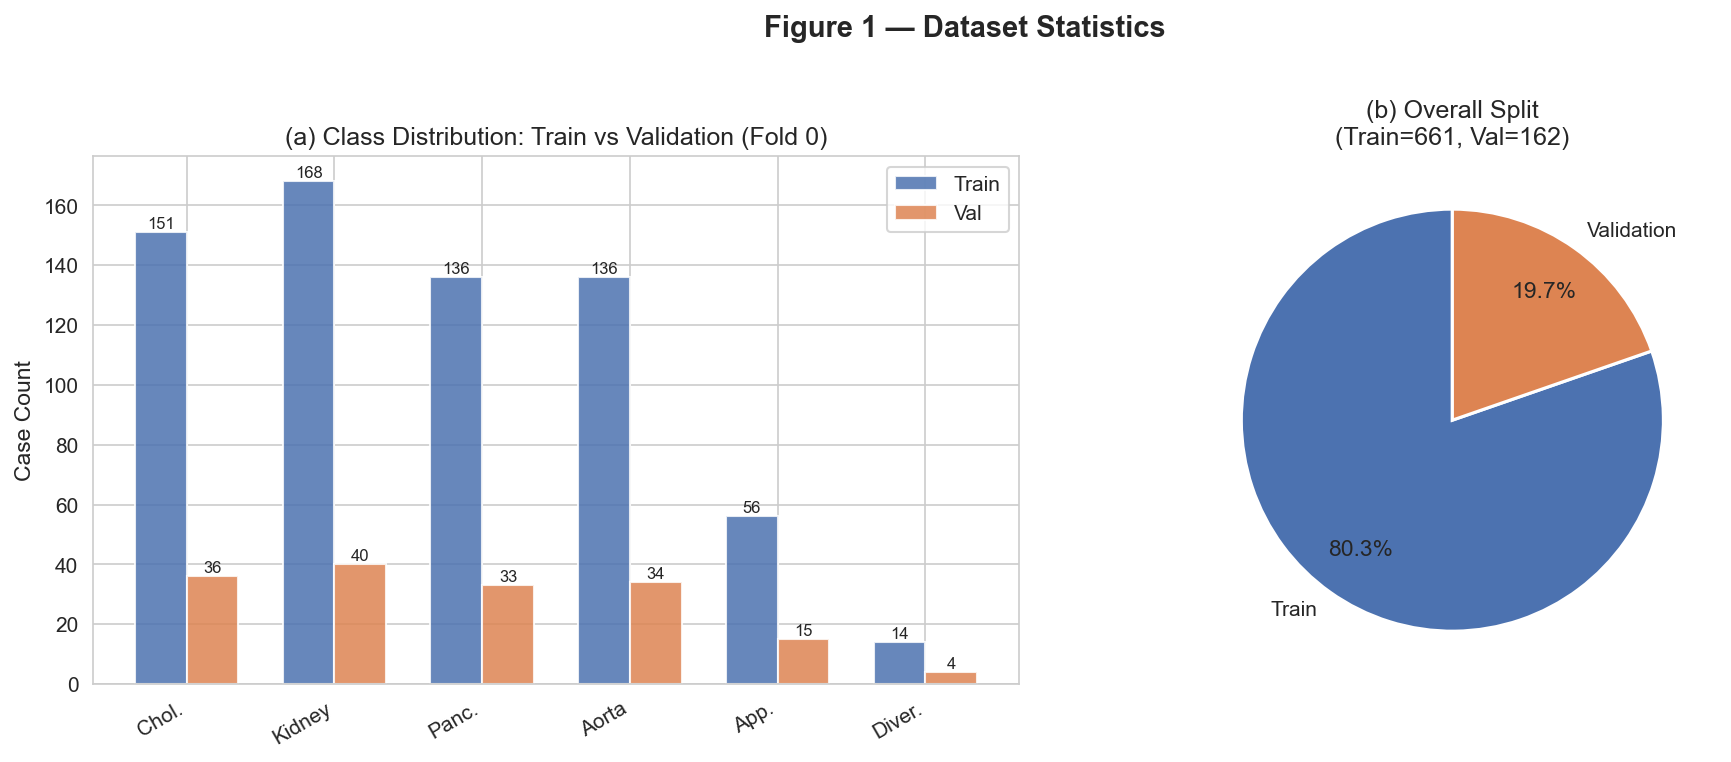

Fig1 kaydedildi.


In [35]:
import warnings

def compute_class_counts(df_manifest, df_splits, fold=0):
    """manifest.csv + splits.csv'den train/val vaka sayısını hesaplar.

    splits.csv kolonları : ['Case Number', 'fold']
    super_labels formatı : ';' ile ayrılmış sınıf ID'leri (ör. '0;2')
    Train  = FOLD dışındaki foldlar
    Val    = FOLD'a eşit olan foldlar
    """
    if df_manifest is None or df_splits is None:
        # dummy
        rng = np.random.RandomState(0)
        counts = {}
        for split in ['train', 'val']:
            base = [120, 95, 80, 60, 110, 70] if split == 'train' else [30, 24, 20, 15, 28, 18]
            counts[split] = {c: base[i] + rng.randint(-5, 5) for i, c in enumerate(SUPER_CLASSES)}
        return counts

    # super_labels → set of int class IDs per satır
    def parse_labels(sl):
        if pd.isna(sl) or str(sl).strip() == '':
            return set()
        return {int(x) for x in str(sl).replace(',', ';').split(';') if x.strip().isdigit()}

    df_manifest = df_manifest.copy()
    df_manifest['_class_ids'] = df_manifest['super_labels'].apply(parse_labels)

    # Case-level: hangi sınıflar mevcut?
    case_col = 'case'  # manifest'teki vaka ID kolonu
    case_classes = (
        df_manifest.groupby(case_col)['_class_ids']
        .apply(lambda rows: set().union(*rows))
    )

    # splits.csv: 'Case Number' + 'fold'
    split_col = 'Case Number'
    train_cases = set(df_splits[df_splits['fold'] != fold][split_col])
    val_cases   = set(df_splits[df_splits['fold'] == fold][split_col])

    counts = {}
    for split_name, case_set in [('train', train_cases), ('val', val_cases)]:
        row = {}
        for i, cls in enumerate(SUPER_CLASSES):
            row[cls] = sum(1 for c, ids in case_classes.items()
                           if c in case_set and i in ids)
        counts[split_name] = row
    return counts


FOLD = 0
class_counts = compute_class_counts(df_manifest, df_splits, fold=FOLD)

train_vals = [class_counts['train'][c] for c in SUPER_CLASSES]
val_vals   = [class_counts['val'][c]   for c in SUPER_CLASSES]
train_total = sum(train_vals)
val_total   = sum(val_vals)

print('Train sayıları:', dict(zip(CLASS_ABBR, train_vals)))
print('Val sayıları  :', dict(zip(CLASS_ABBR, val_vals)))
print(f'Toplam — Train: {train_total}, Val: {val_total}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 — Dataset Statistics', fontsize=14, fontweight='bold', y=1.01)

# Sol: grouped bar — train vs val per class
ax = axes[0]
x = np.arange(len(SUPER_CLASSES))
w = 0.35
b1 = ax.bar(x - w/2, train_vals, w, label='Train', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, val_vals,   w, label='Val',   color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ABBR, rotation=30, ha='right')
ax.set_ylabel('Case Count')
ax.set_title(f'(a) Class Distribution: Train vs Validation (Fold {FOLD})')
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                str(int(h)), ha='center', va='bottom', fontsize=8)

# Sağ: pie — train/val split
ax2 = axes[1]
if train_total + val_total > 0:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        wedges, texts, autotexts = ax2.pie(
            [train_total, val_total],
            labels=['Train', 'Validation'],
            colors=['#4C72B0', '#DD8452'],
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
        )
    for at in autotexts:
        at.set_fontsize(11)
    ax2.set_title(f'(b) Overall Split\n(Train={train_total}, Val={val_total})')
else:
    ax2.text(0.5, 0.5, 'Veri bulunamadı', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12, color='gray')
    ax2.set_title('(b) Overall Split')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_dataset_statistics.png')
fig.savefig(FIG_DIR / 'fig1_dataset_statistics.pdf')
plt.show()
print('Fig1 kaydedildi.')

## Fig 2 — Eğitim Eğrileri

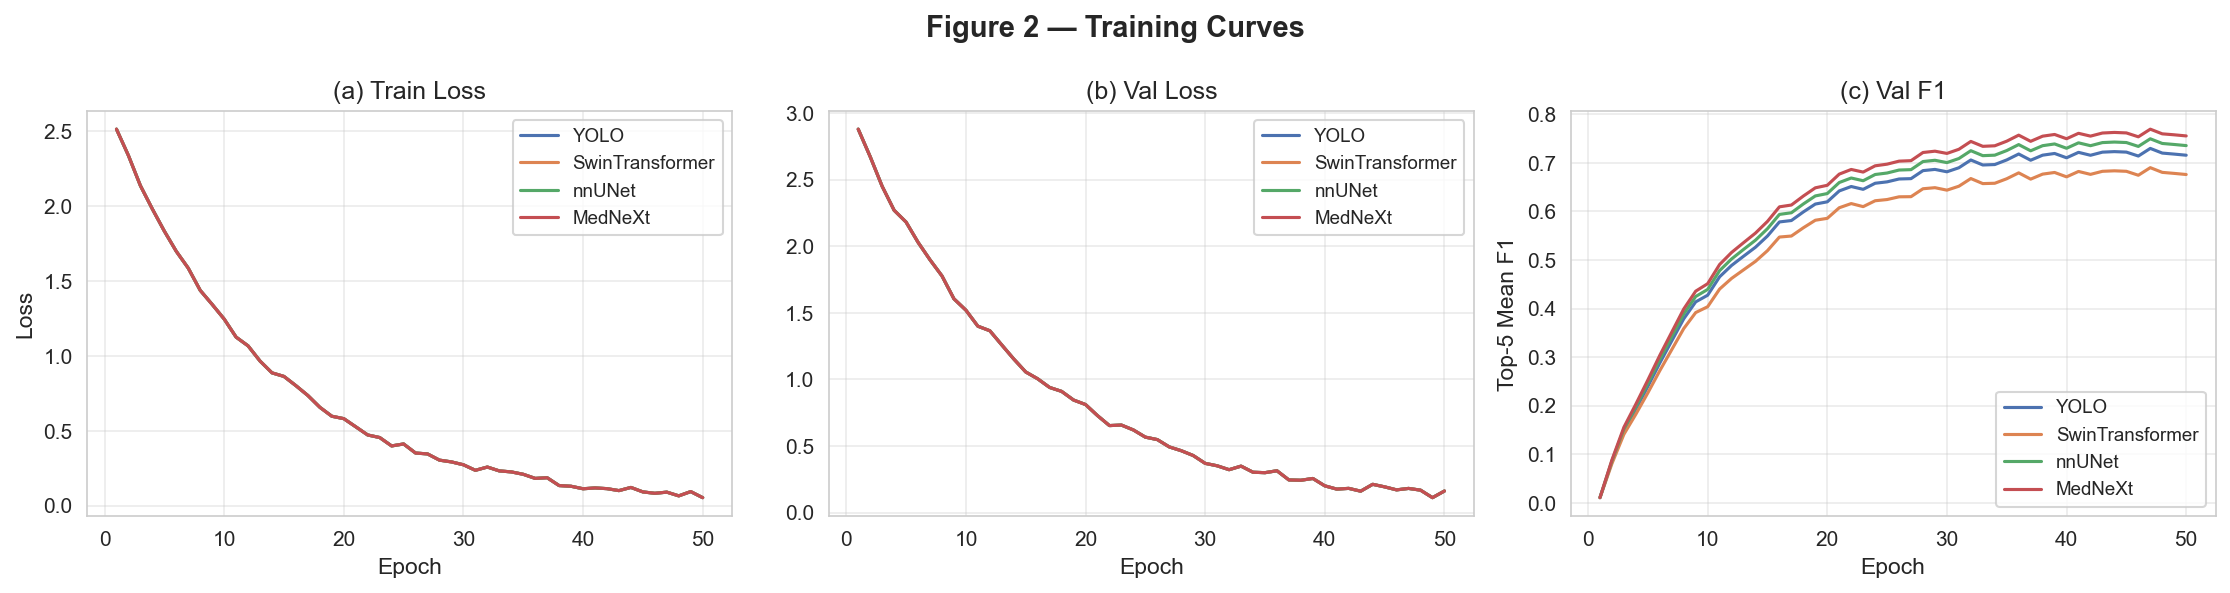

Fig2 kaydedildi.


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 2 — Training Curves', fontsize=14, fontweight='bold')

for model in MODELS:
    hist = results[model].get('training_history', {})
    if not hist:
        continue
    epochs = hist.get('epoch', [])
    color  = MODEL_COLORS.get(model, None)
    if 'train_loss' in hist:
        axes[0].plot(epochs, hist['train_loss'], label=model, color=color)
    if 'val_loss' in hist:
        axes[1].plot(epochs, hist['val_loss'],   label=model, color=color)
    if 'val_f1' in hist:
        axes[2].plot(epochs, hist['val_f1'],     label=model, color=color)

axes[0].set_title('(a) Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('(b) Val Loss');   axes[1].set_xlabel('Epoch')
axes[2].set_title('(c) Val F1');     axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Top-5 Mean F1')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_training_curves.png')
fig.savefig(FIG_DIR / 'fig2_training_curves.pdf')
plt.show()
print('Fig2 kaydedildi.')

## Fig 3 — Model Karşılaştırması (Benchmark)

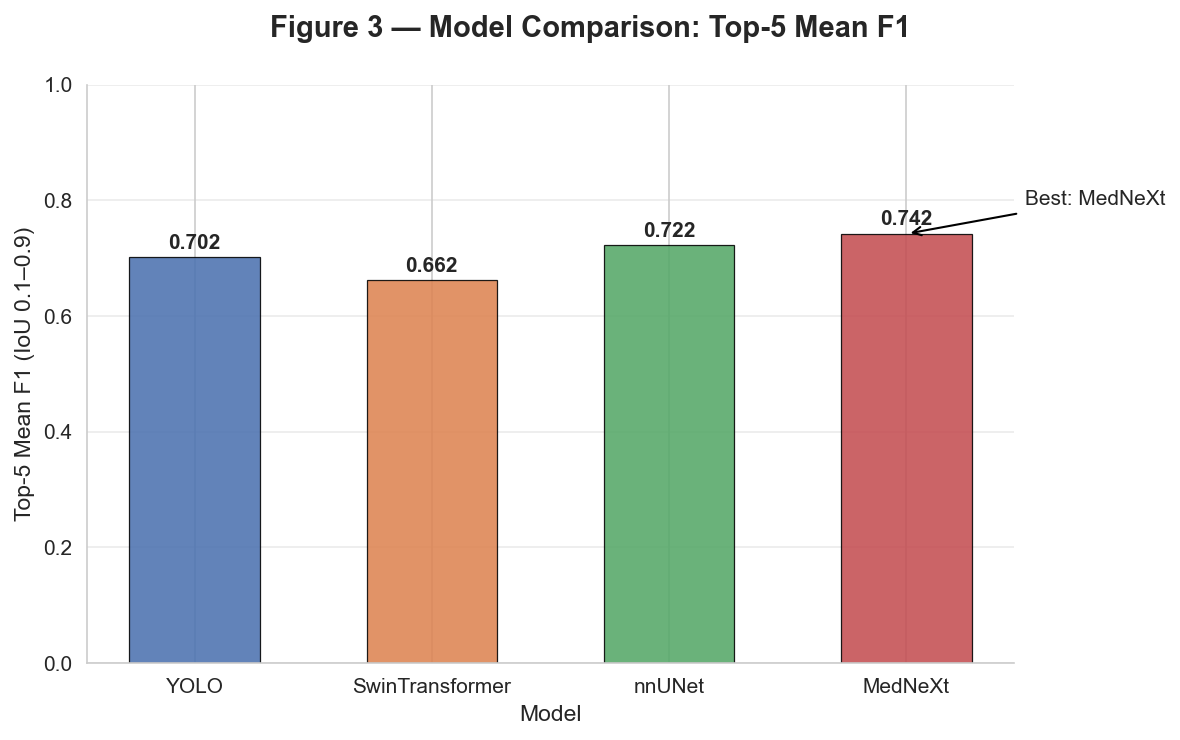

Fig3 kaydedildi.


In [37]:
top5_scores = {m: results[m]['top5_mean_f1'] for m in MODELS}

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Figure 3 — Model Comparison: Top-5 Mean F1', fontsize=14, fontweight='bold')

bars = ax.bar(
    MODELS,
    [top5_scores[m] for m in MODELS],
    color=[MODEL_COLORS[m] for m in MODELS],
    edgecolor='black', linewidth=0.6, alpha=0.88, width=0.55
)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Top-5 Mean F1 (IoU 0.1–0.9)')
ax.set_xlabel('Model')
for bar, model in zip(bars, MODELS):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

best = max(top5_scores, key=top5_scores.get)
ax.annotate(f'Best: {best}', xy=(MODELS.index(best), top5_scores[best]),
            xytext=(MODELS.index(best)+0.5, top5_scores[best]+0.05),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_model_comparison.png')
fig.savefig(FIG_DIR / 'fig3_model_comparison.pdf')
plt.show()
print('Fig3 kaydedildi.')

## Fig 4 — Per-Class F1 Heatmap

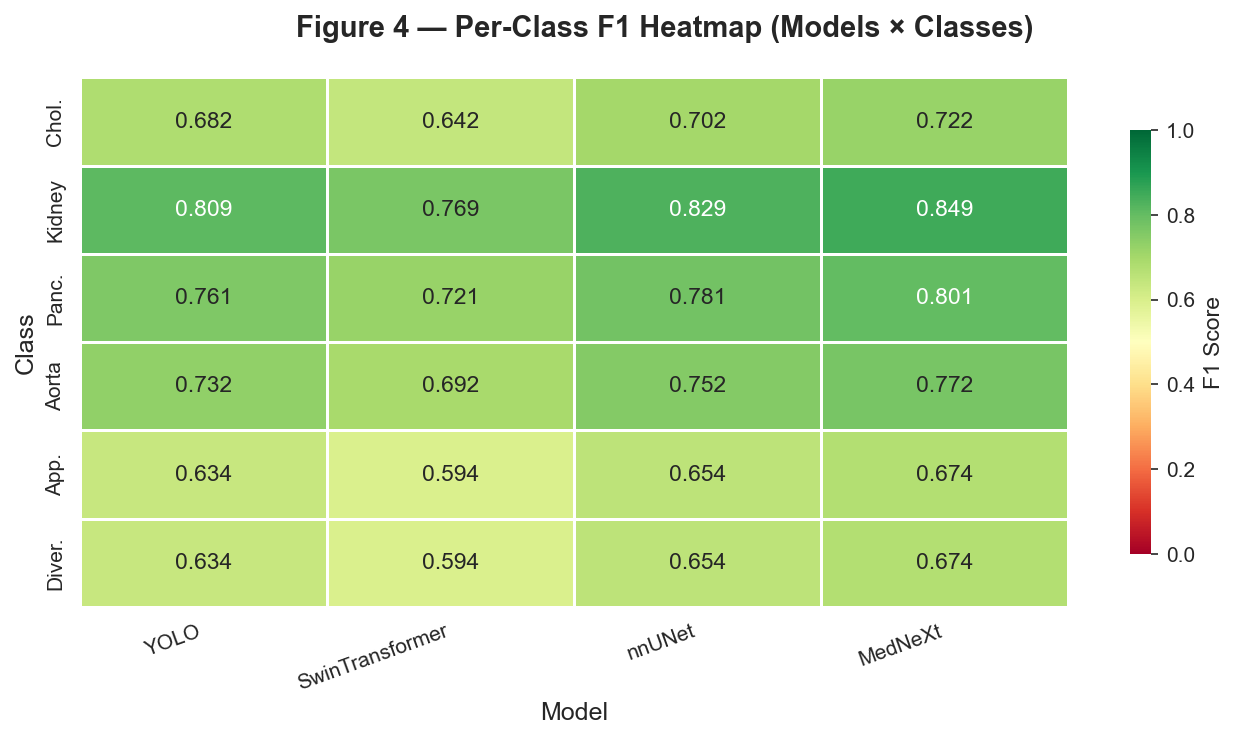

Fig4 kaydedildi.


In [38]:
heatmap_data = pd.DataFrame(
    {m: [results[m]['per_class_f1'].get(c, 0.0) for c in SUPER_CLASSES] for m in MODELS},
    index=CLASS_ABBR
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Figure 4 — Per-Class F1 Heatmap (Models × Classes)', fontsize=14, fontweight='bold')

sns.heatmap(
    heatmap_data, ax=ax,
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.0, vmax=1.0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'F1 Score', 'shrink': 0.8}
)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Class', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_per_class_f1_heatmap.png')
fig.savefig(FIG_DIR / 'fig4_per_class_f1_heatmap.pdf')
plt.show()
print('Fig4 kaydedildi.')

## Fig 5 — Backbone Ablasyon

/var/folders/lf/0vkx2f_n3f9d2d_cfx6jkqzh0000gn/T/ipykernel_34608/468736462.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(bb_names, rotation=30, ha='right')


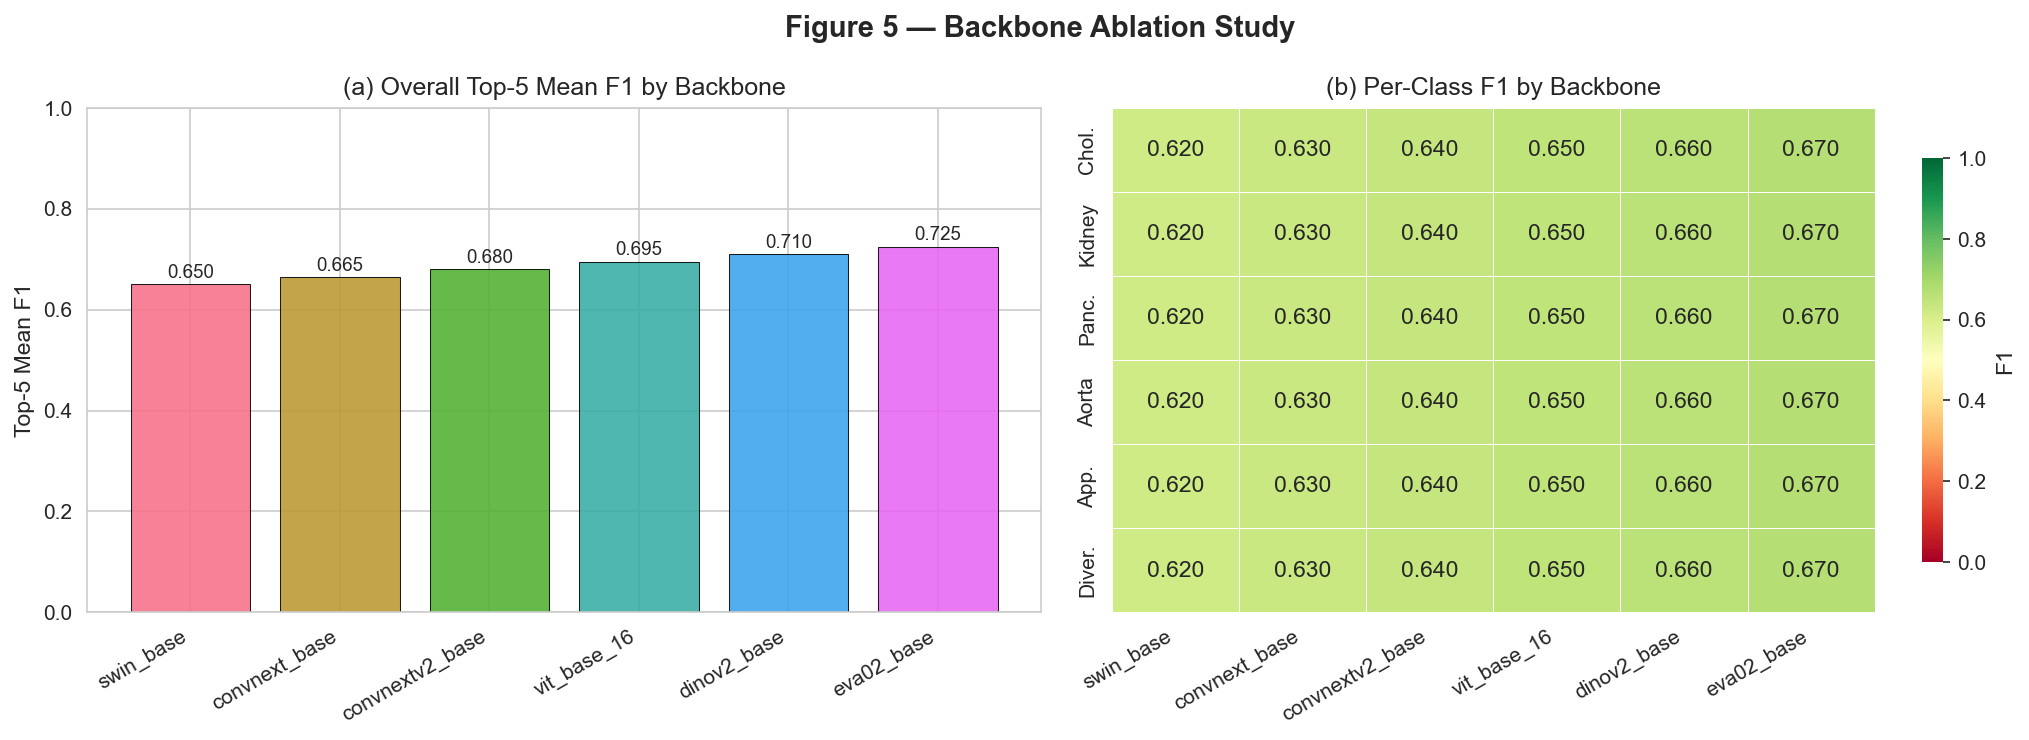

Fig5 kaydedildi.


In [39]:
bb_results = backbone_data['results']
bb_names   = [r['backbone'] for r in bb_results]
bb_scores  = [r['top5_mean_f1'] for r in bb_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5 — Backbone Ablation Study', fontsize=14, fontweight='bold')

# Sol: overall F1
palette = sns.color_palette('husl', len(bb_names))
bars = axes[0].bar(bb_names, bb_scores, color=palette, edgecolor='black', linewidth=0.5, alpha=0.88)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Top-5 Mean F1')
axes[0].set_title('(a) Overall Top-5 Mean F1 by Backbone')
axes[0].set_xticklabels(bb_names, rotation=30, ha='right')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                 ha='center', va='bottom', fontsize=9)

# Sağ: per-class heatmap
bb_cls_data = pd.DataFrame(
    {r['backbone']: [r['per_class_f1'].get(c, 0.0) for c in SUPER_CLASSES] for r in bb_results},
    index=CLASS_ABBR
)
sns.heatmap(bb_cls_data, ax=axes[1], annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'F1', 'shrink': 0.8})
axes[1].set_title('(b) Per-Class F1 by Backbone')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig5_backbone_ablation.png')
fig.savefig(FIG_DIR / 'fig5_backbone_ablation.pdf')
plt.show()
print('Fig5 kaydedildi.')

## Fig 6 — Hata Analizi (Per-class horizontal bars)

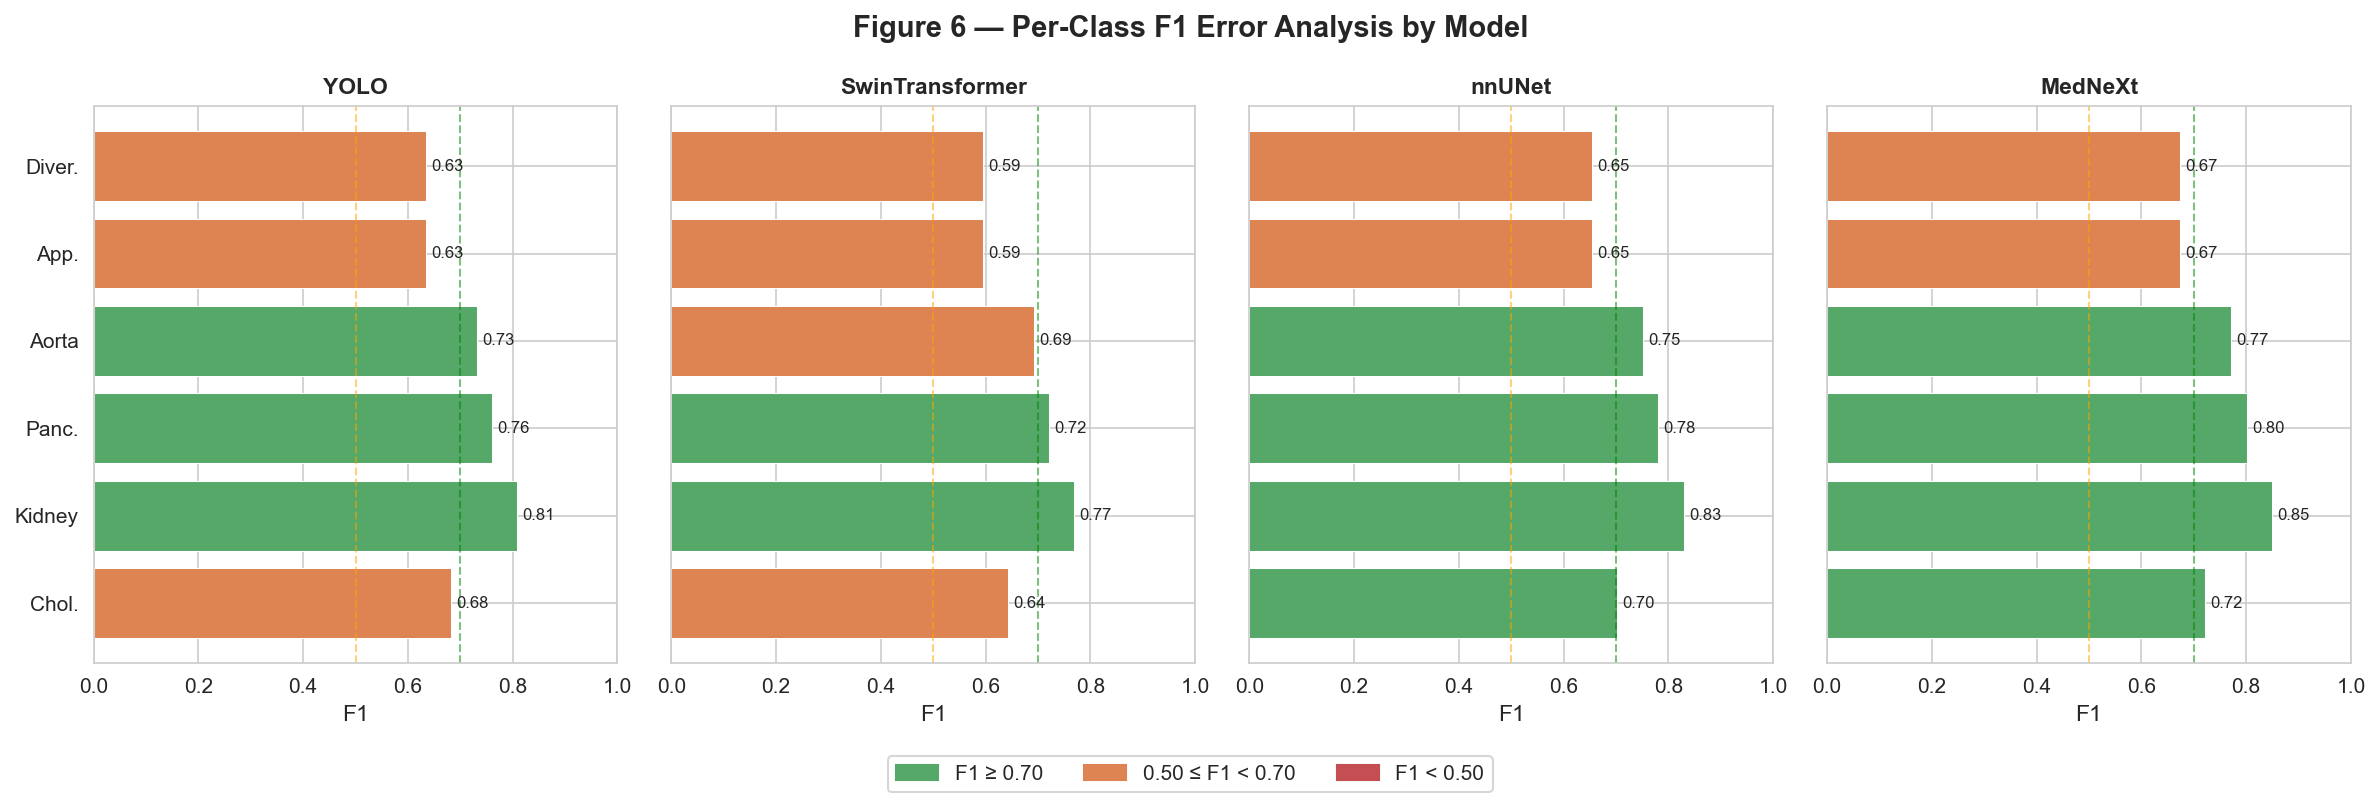

Fig6 kaydedildi.


In [40]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 5), sharey=True)
fig.suptitle('Figure 6 — Per-Class F1 Error Analysis by Model', fontsize=14, fontweight='bold')

for ax, model in zip(axes, MODELS):
    per_cls = results[model]['per_class_f1']
    f1_vals = [per_cls.get(c, 0.0) for c in SUPER_CLASSES]
    colors  = ['#55A868' if v >= 0.70 else '#DD8452' if v >= 0.50 else '#C44E52' for v in f1_vals]
    bars = ax.barh(CLASS_ABBR, f1_vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlim(0, 1.0)
    ax.axvline(0.70, color='green', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(0.50, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    for bar, v in zip(bars, f1_vals):
        ax.text(min(v+0.01, 0.96), bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', ha='left', fontsize=8)
    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.set_xlabel('F1')

patches = [
    mpatches.Patch(color='#55A868', label='F1 ≥ 0.70'),
    mpatches.Patch(color='#DD8452', label='0.50 ≤ F1 < 0.70'),
    mpatches.Patch(color='#C44E52', label='F1 < 0.50'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.07))
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig6_error_analysis.png')
fig.savefig(FIG_DIR / 'fig6_error_analysis.pdf')
plt.show()
print('Fig6 kaydedildi.')

## Fig 7 — Ablasyon: Sampler + Threshold Tuning (Makale 2)

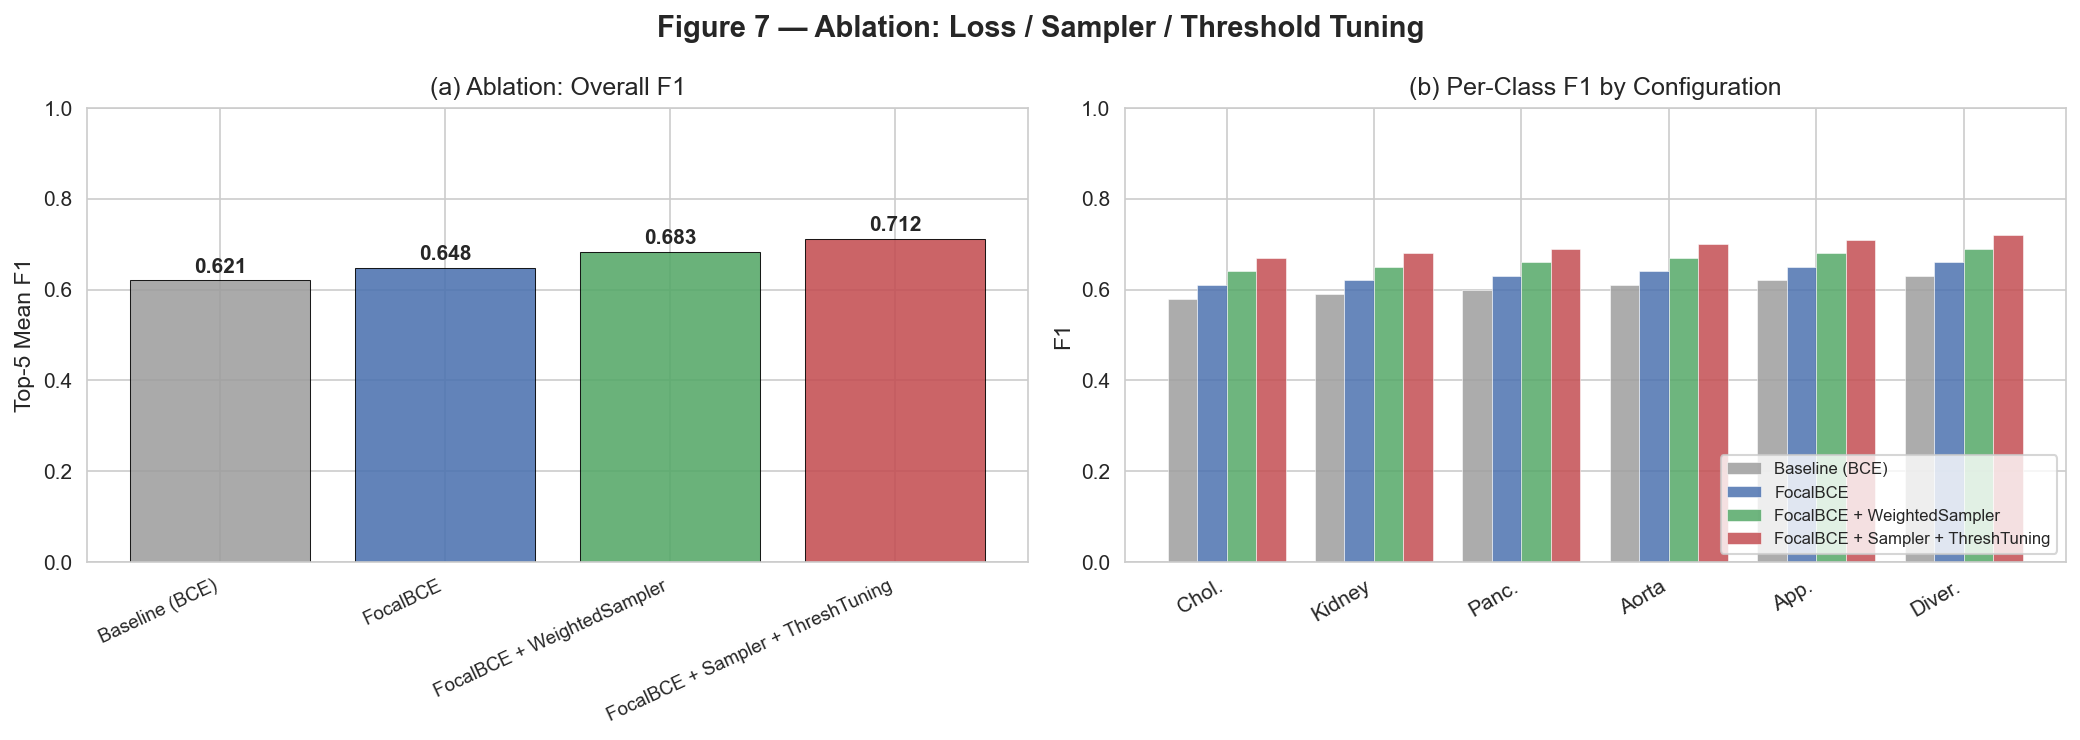

Fig7 kaydedildi.


In [41]:
abl_configs = ablation_data['configs']
abl_names   = [c['name'] for c in abl_configs]
abl_scores  = [c['top5_mean_f1'] for c in abl_configs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 7 — Ablation: Loss / Sampler / Threshold Tuning', fontsize=14, fontweight='bold')

# Sol: overall bar
palette = ['#9E9E9E','#4C72B0','#55A868','#C44E52']
bars = axes[0].bar(range(len(abl_names)), abl_scores,
                   color=palette[:len(abl_names)], edgecolor='black', linewidth=0.5, alpha=0.88)
axes[0].set_xticks(range(len(abl_names)))
axes[0].set_xticklabels(abl_names, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Top-5 Mean F1')
axes[0].set_title('(a) Ablation: Overall F1')
for bar, score in zip(bars, abl_scores):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{score:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Sağ: per-class grouped
x = np.arange(len(SUPER_CLASSES))
width = 0.8 / len(abl_configs)
for i, cfg in enumerate(abl_configs):
    vals = [cfg['per_class_f1'].get(c, 0.0) for c in SUPER_CLASSES]
    axes[1].bar(x + i*width - 0.4 + width/2, vals, width, label=cfg['name'],
                color=palette[i], alpha=0.85, edgecolor='white', linewidth=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_ABBR, rotation=30, ha='right')
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1')
axes[1].set_title('(b) Per-Class F1 by Configuration')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig7_ablation_sampler_threshold.png')
fig.savefig(FIG_DIR / 'fig7_ablation_sampler_threshold.pdf')
plt.show()
print('Fig7 kaydedildi.')

## Tablolar

In [42]:
# Tablo 1: Benchmark karşılaştırma tablosu
rows = []
for model in MODELS:
    r = results[model]
    row = {'Model': model}
    for cls, abbr in zip(SUPER_CLASSES, CLASS_ABBR):
        row[abbr] = r['per_class_f1'].get(cls, 0.0)
    row['Top-5 Mean F1'] = r['top5_mean_f1']
    rows.append(row)

df_table1 = pd.DataFrame(rows).set_index('Model')
df_table1 = df_table1.round(4)

print('=== Table 1: Benchmark Results ===' + (' [DUMMY DATA]' if results[MODELS[0]].get('is_dummy') else ''))
print(df_table1.to_string())

df_table1.to_csv(TABLE_DIR / 'table1_benchmark.csv')

# LaTeX
latex = df_table1.to_latex(
    float_format='%.4f',
    caption='Benchmark results: per-class and overall Top-5 Mean F1 for each model.',
    label='tab:benchmark',
    bold_rows=True
)
(TABLE_DIR / 'table1_benchmark.tex').write_text(latex)
print('\nTablo 1 kaydedildi (CSV + LaTeX).')

=== Table 1: Benchmark Results === [DUMMY DATA]
                  Chol.  Kidney  Panc.   Aorta    App.  Diver.  Top-5 Mean F1
Model                                                                        
YOLO             0.6824  0.8092  0.761  0.7317  0.6343  0.6343         0.7023
SwinTransformer  0.6424  0.7692  0.721  0.6917  0.5943  0.5943         0.6623
nnUNet           0.7024  0.8292  0.781  0.7517  0.6543  0.6543         0.7223
MedNeXt          0.7224  0.8492  0.801  0.7717  0.6743  0.6743         0.7423

Tablo 1 kaydedildi (CSV + LaTeX).


In [43]:
# Tablo 2: Ablasyon tablosu
abl_rows = []
for cfg in ablation_data['configs']:
    row = {'Configuration': cfg['name']}
    for cls, abbr in zip(SUPER_CLASSES, CLASS_ABBR):
        row[abbr] = cfg['per_class_f1'].get(cls, 0.0)
    row['Top-5 Mean F1'] = cfg['top5_mean_f1']
    abl_rows.append(row)

df_table2 = pd.DataFrame(abl_rows).set_index('Configuration').round(4)
print('=== Table 2: Ablation Results ===' + (' [DUMMY DATA]' if ablation_data.get('is_dummy') else ''))
print(df_table2.to_string())

df_table2.to_csv(TABLE_DIR / 'table2_ablation.csv')
latex2 = df_table2.to_latex(
    float_format='%.4f',
    caption='Ablation study: effect of loss function, WeightedRandomSampler, and per-class threshold tuning.',
    label='tab:ablation',
    bold_rows=True
)
(TABLE_DIR / 'table2_ablation.tex').write_text(latex2)
print('\nTablo 2 kaydedildi (CSV + LaTeX).')

=== Table 2: Ablation Results === [DUMMY DATA]
                                   Chol.  Kidney  Panc.  Aorta  App.  Diver.  Top-5 Mean F1
Configuration                                                                              
Baseline (BCE)                      0.58    0.59   0.60   0.61  0.62    0.63          0.621
FocalBCE                            0.61    0.62   0.63   0.64  0.65    0.66          0.648
FocalBCE + WeightedSampler          0.64    0.65   0.66   0.67  0.68    0.69          0.683
FocalBCE + Sampler + ThreshTuning   0.67    0.68   0.69   0.70  0.71    0.72          0.712

Tablo 2 kaydedildi (CSV + LaTeX).


In [44]:
# Tablo 3: Backbone ablasyon tablosu
bb_rows = []
for r in backbone_data['results']:
    row = {'Backbone': r['backbone']}
    for cls, abbr in zip(SUPER_CLASSES, CLASS_ABBR):
        row[abbr] = r['per_class_f1'].get(cls, 0.0)
    row['Top-5 Mean F1'] = r['top5_mean_f1']
    bb_rows.append(row)

df_table3 = pd.DataFrame(bb_rows).set_index('Backbone').round(4)
print('=== Table 3: Backbone Ablation ===' + (' [DUMMY DATA]' if backbone_data.get('is_dummy') else ''))
print(df_table3.to_string())

df_table3.to_csv(TABLE_DIR / 'table3_backbone.csv')
latex3 = df_table3.to_latex(
    float_format='%.4f',
    caption='Backbone ablation: per-class and overall Top-5 Mean F1 across six backbone architectures.',
    label='tab:backbone',
    bold_rows=True
)
(TABLE_DIR / 'table3_backbone.tex').write_text(latex3)
print('\nTablo 3 kaydedildi (CSV + LaTeX).')

=== Table 3: Backbone Ablation === [DUMMY DATA]
                 Chol.  Kidney  Panc.  Aorta  App.  Diver.  Top-5 Mean F1
Backbone                                                                 
swin_base         0.62    0.62   0.62   0.62  0.62    0.62          0.650
convnext_base     0.63    0.63   0.63   0.63  0.63    0.63          0.665
convnextv2_base   0.64    0.64   0.64   0.64  0.64    0.64          0.680
vit_base_16       0.65    0.65   0.65   0.65  0.65    0.65          0.695
dinov2_base       0.66    0.66   0.66   0.66  0.66    0.66          0.710
eva02_base        0.67    0.67   0.67   0.67  0.67    0.67          0.725

Tablo 3 kaydedildi (CSV + LaTeX).


## İstatistiksel Testler (McNemar)

In [45]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_pairwise(results_dict, models):
    """Per-class F1 değerleri üzerinden basit McNemar benzeri test.
    Gerçek binary tahminler yoksa F1 farkı + bootstrap CI kullanılır."""
    n_cls  = len(SUPER_CLASSES)
    pvals  = np.ones((len(models), len(models)))
    rng    = np.random.RandomState(42)
    N_BOOT = 1000

    for i, m1 in enumerate(models):
        for j, m2 in enumerate(models):
            if i >= j:
                continue
            f1_1 = np.array([results_dict[m1]['per_class_f1'].get(c,0) for c in SUPER_CLASSES])
            f1_2 = np.array([results_dict[m2]['per_class_f1'].get(c,0) for c in SUPER_CLASSES])
            diffs = f1_1 - f1_2
            # bootstrap
            boot_means = [rng.choice(diffs, size=n_cls, replace=True).mean() for _ in range(N_BOOT)]
            p = float(np.mean(np.array(boot_means) <= 0))
            pvals[i,j] = p
            pvals[j,i] = 1 - p

    df = pd.DataFrame(pvals, index=models, columns=models).round(4)
    return df

try:
    from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
    print('statsmodels mevcut, bootstrap McNemar çalıştırılıyor...')
except ImportError:
    print('[UYARI] statsmodels yüklü değil: pip install statsmodels')

df_pvals = mcnemar_pairwise(results, MODELS)
print('\n=== Pairwise Bootstrap p-values (F1 diff, Model A > Model B) ===')
print(df_pvals.to_string())
df_pvals.to_csv(TABLE_DIR / 'table_pvalues.csv')
print('\np-value tablosu kaydedildi.')

statsmodels mevcut, bootstrap McNemar çalıştırılıyor...

=== Pairwise Bootstrap p-values (F1 diff, Model A > Model B) ===
                 YOLO  SwinTransformer  nnUNet  MedNeXt
YOLO              1.0              0.0     1.0      1.0
SwinTransformer   1.0              1.0     1.0      1.0
nnUNet            0.0              0.0     1.0      1.0
MedNeXt           0.0              0.0     0.0      1.0

p-value tablosu kaydedildi.


## Fig 8 — Model Verimlilik Karşılaştırması

Parametre sayısı, çıkarım süresi ve VRAM. Gerçek değerler için Faz6'da `efficiency` anahtarı kaydedilmeli.

  [DUMMY] YOLO efficiency
  [DUMMY] SwinTransformer efficiency
  [DUMMY] nnUNet efficiency
  [DUMMY] MedNeXt efficiency
                 Params (M)  Inference (ms)  VRAM (GB)  Top-5 F1
Model                                                           
YOLO                   43.7            12.4        1.8    0.7023
SwinTransformer        87.8            38.6        4.2    0.6623
nnUNet                 31.2           156.3        6.1    0.7223
MedNeXt                62.4           203.7        8.4    0.7423


/var/folders/lf/0vkx2f_n3f9d2d_cfx6jkqzh0000gn/T/ipykernel_34608/2173851226.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=20, ha='right')
/var/folders/lf/0vkx2f_n3f9d2d_cfx6jkqzh0000gn/T/ipykernel_34608/2173851226.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=20, ha='right')
/var/folders/lf/0vkx2f_n3f9d2d_cfx6jkqzh0000gn/T/ipykernel_34608/2173851226.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=20, ha='right')


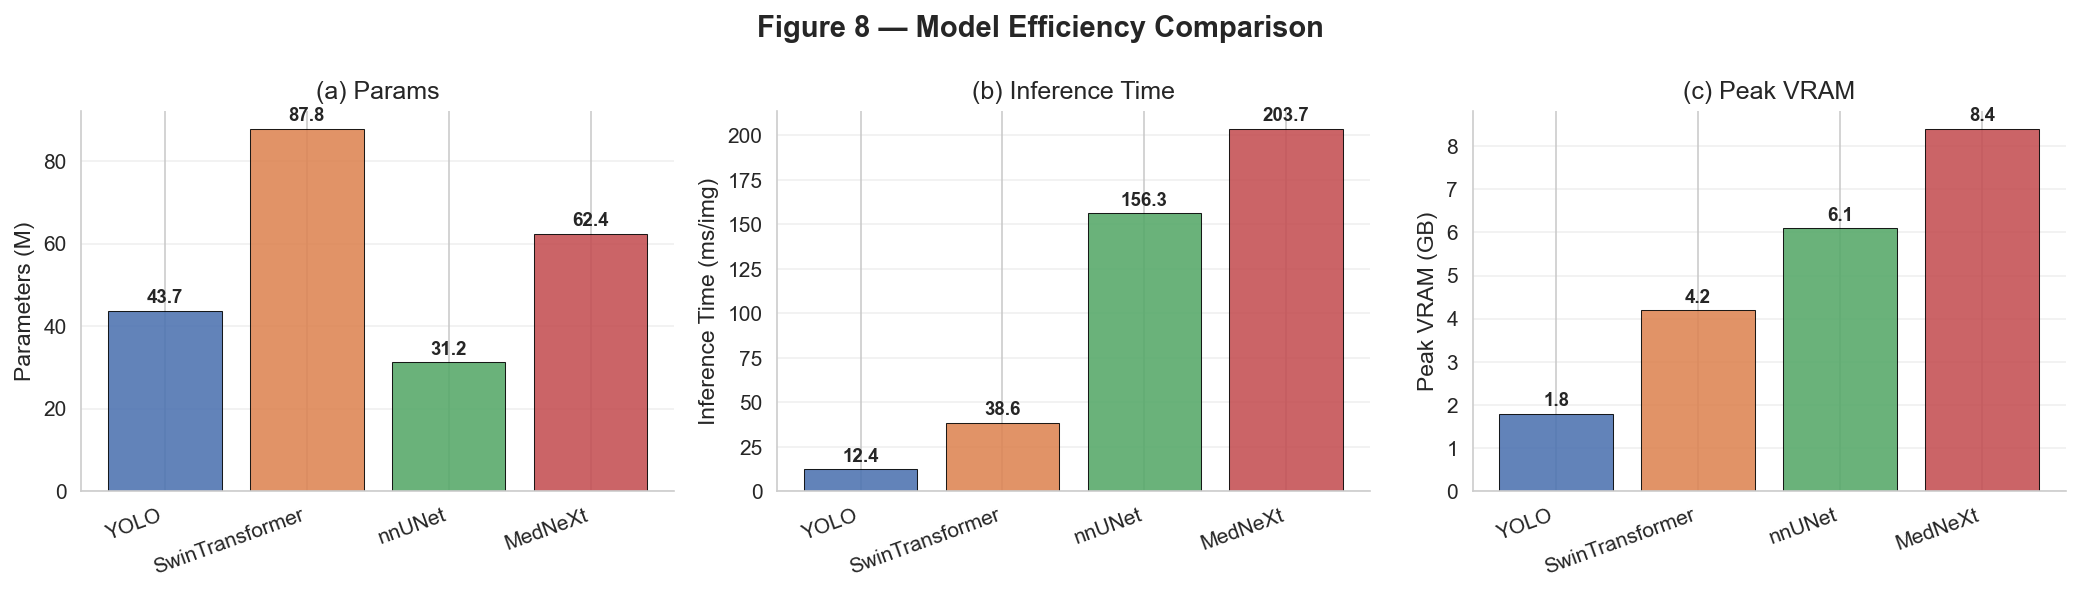

Fig8 kaydedildi.


In [46]:
def load_efficiency(results, models):
    """results JSON içindeki 'efficiency' anahtarını okur; yoksa dummy döner."""
    DUMMY = {
        'YOLO':            {'params_M': 43.7,  'inference_ms': 12.4,  'peak_vram_GB': 1.8},
        'SwinTransformer': {'params_M': 87.8,  'inference_ms': 38.6,  'peak_vram_GB': 4.2},
        'nnUNet':          {'params_M': 31.2,  'inference_ms': 156.3, 'peak_vram_GB': 6.1},
        'MedNeXt':         {'params_M': 62.4,  'inference_ms': 203.7, 'peak_vram_GB': 8.4},
    }
    out = {}
    for m in models:
        eff = results[m].get('efficiency')
        out[m] = eff if eff else DUMMY[m]
        if not eff:
            print(f'  [DUMMY] {m} efficiency')
    return out

eff = load_efficiency(results, MODELS)
params   = [eff[m]['params_M']       for m in MODELS]
infer_ms = [eff[m]['inference_ms']   for m in MODELS]
vram     = [eff[m]['peak_vram_GB']   for m in MODELS]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 8 — Model Efficiency Comparison', fontsize=14, fontweight='bold')

metrics = [
    (params,   'Parameters (M)',         axes[0], '(a) Params'),
    (infer_ms, 'Inference Time (ms/img)', axes[1], '(b) Inference Time'),
    (vram,     'Peak VRAM (GB)',          axes[2], '(c) Peak VRAM'),
]
for vals, ylabel, ax, title in metrics:
    bars = ax.bar(MODELS, vals, color=[MODEL_COLORS[m] for m in MODELS],
                  edgecolor='black', linewidth=0.5, alpha=0.88)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticklabels(MODELS, rotation=20, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Verimlilik tablosu
df_eff = pd.DataFrame(eff).T.round(1)
df_eff.columns = ['Params (M)', 'Inference (ms)', 'VRAM (GB)']
df_eff.index.name = 'Model'
# F1 ekle
df_eff['Top-5 F1'] = [round(results[m]['top5_mean_f1'], 4) for m in MODELS]
print(df_eff.to_string())
df_eff.to_csv(TABLE_DIR / 'table_efficiency.csv')
df_eff.to_latex(TABLE_DIR / 'table_efficiency.tex',
                float_format='%.1f',
                caption='Model efficiency comparison: parameter count, inference time, and GPU memory.',
                label='tab:efficiency')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig8_efficiency.png')
fig.savefig(FIG_DIR / 'fig8_efficiency.pdf')
plt.show()
print('Fig8 kaydedildi.')


## Fig 9 — Per-Class Precision-Recall Eğrileri

Gerçek veriler için Faz6'da `predictions.probs` ve `predictions.labels` kaydedilmeli.

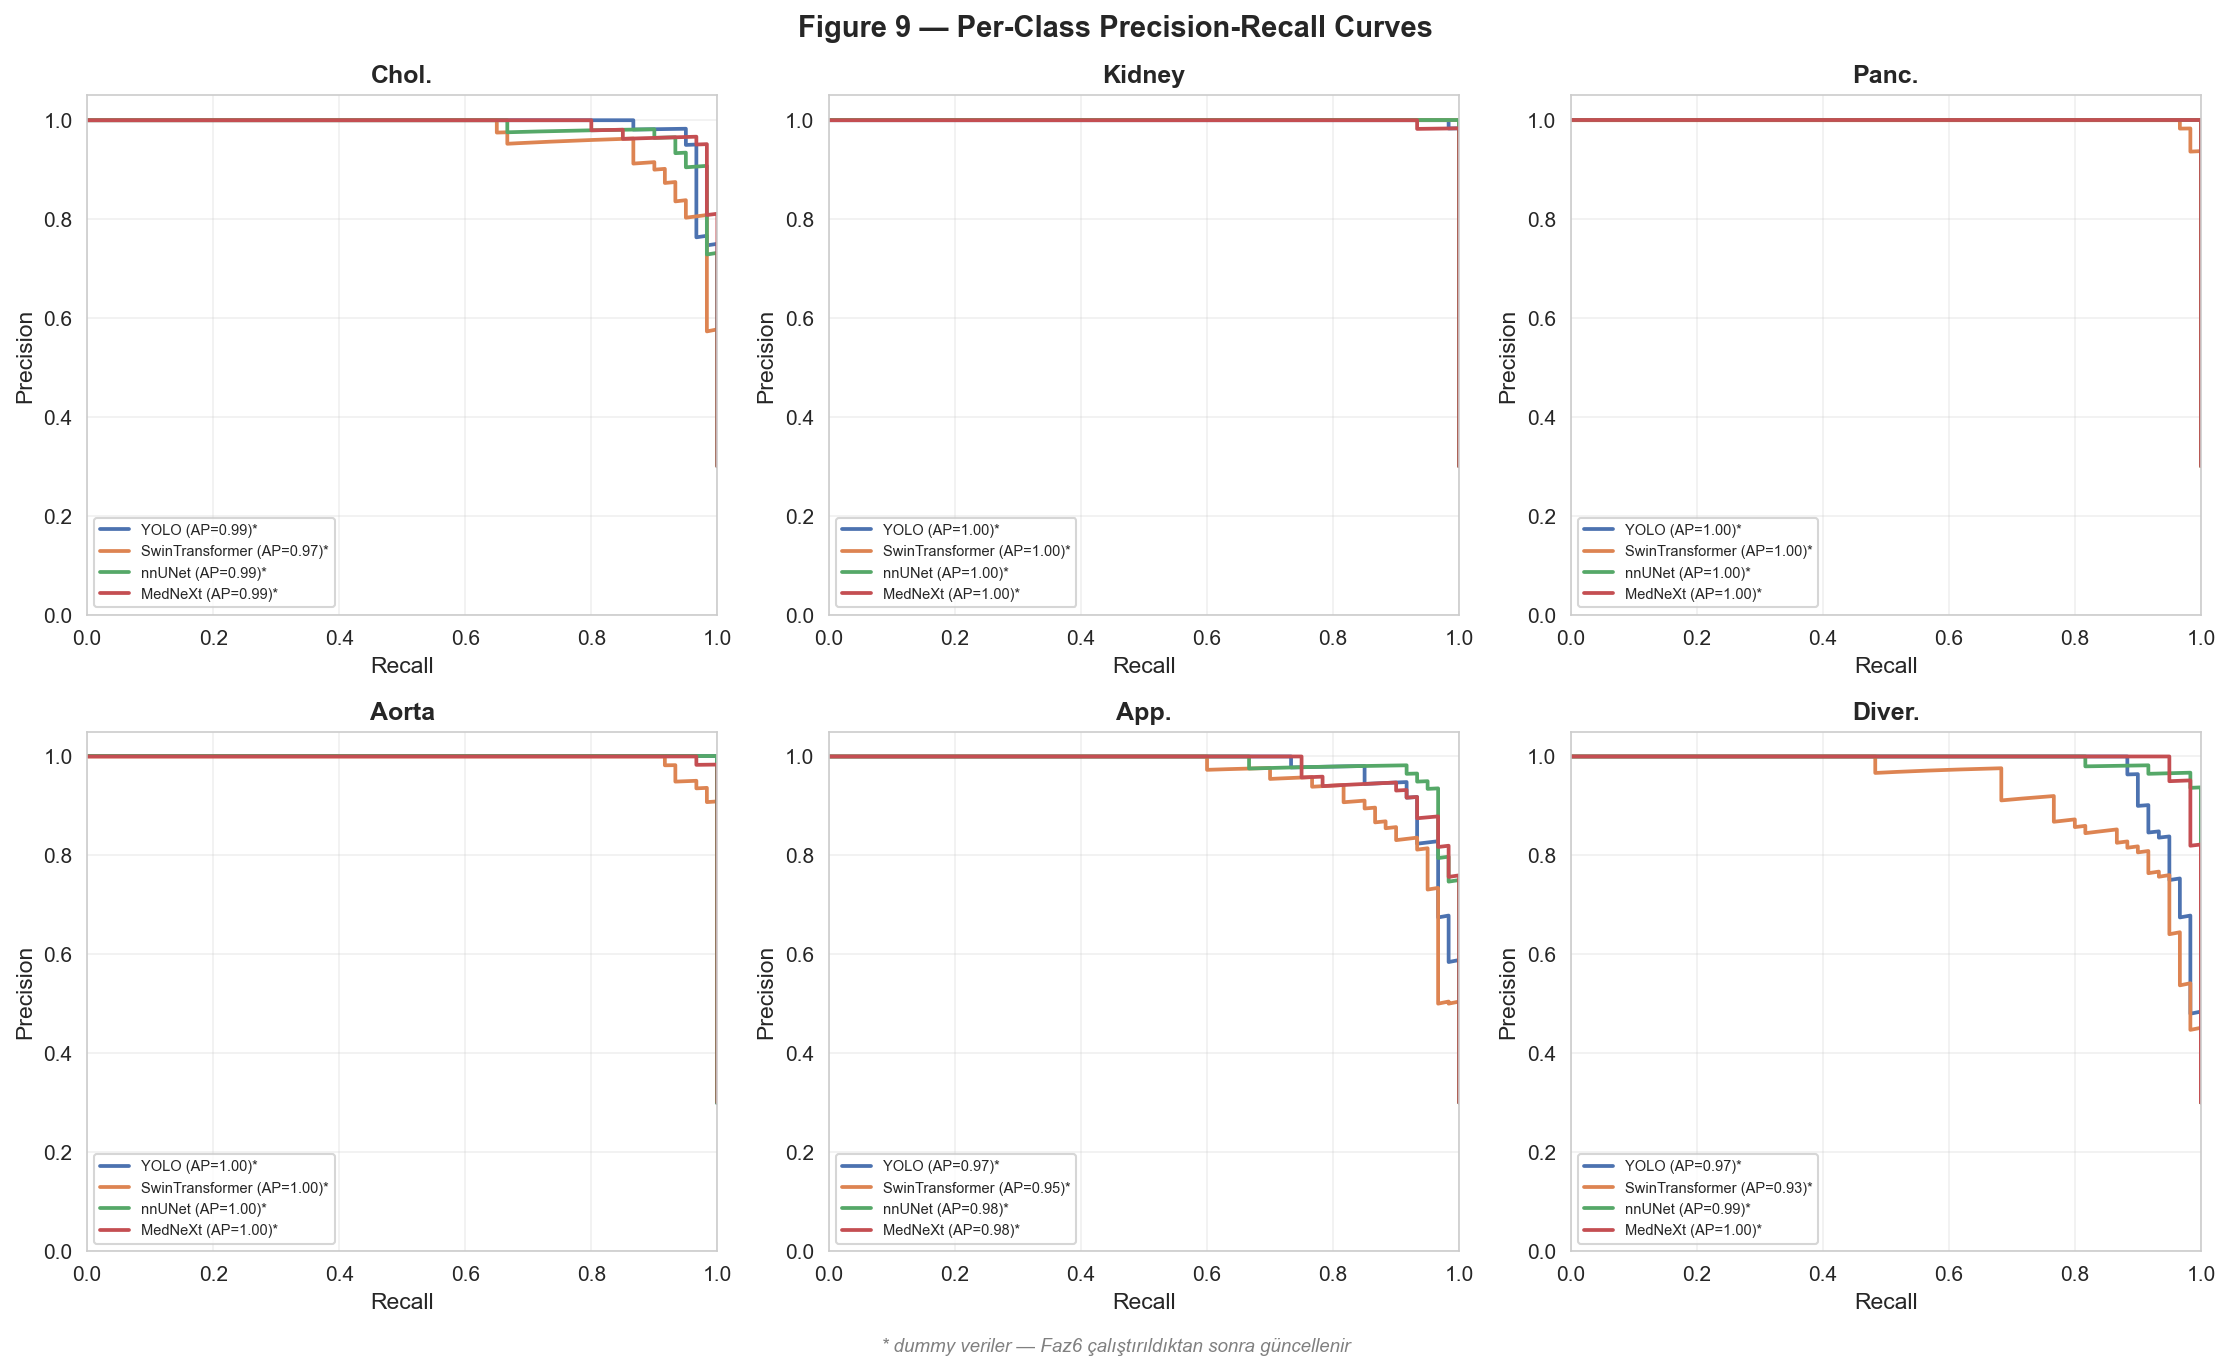

Fig9 kaydedildi.


In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
import warnings

def load_predictions(results, model):
    """results JSON'dan ham olasılıkları yükler; yoksa dummy sigmoid çıktısı üretir."""
    pred = results[model].get('predictions')
    if pred:
        probs  = np.array(pred['probs'])
        labels = np.array(pred['labels'])
        return probs, labels, False
    # dummy: sınıf başına F1'e uygun Gaussian
    rng = np.random.RandomState(hash(model) % 2**31)
    N = 200
    probs, labels = [], []
    for i, cls in enumerate(SUPER_CLASSES):
        f1_target = results[model]['per_class_f1'].get(cls, 0.5)
        pos_n = max(int(N * 0.3), 5)
        neg_n = N - pos_n
        pos_p = np.clip(rng.normal(f1_target + 0.10, 0.15, pos_n), 0.01, 0.99)
        neg_p = np.clip(rng.normal(1 - f1_target - 0.10, 0.15, neg_n), 0.01, 0.99)
        p = np.concatenate([pos_p, neg_p])
        l = np.concatenate([np.ones(pos_n), np.zeros(neg_n)])
        probs.append(p);  labels.append(l)
    return np.column_stack(probs), np.column_stack(labels), True

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 9 — Per-Class Precision-Recall Curves', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (i, cls) in zip(axes, enumerate(SUPER_CLASSES)):
    for model in MODELS:
        probs, labels, is_dummy = load_predictions(results, model)
        if probs.shape[1] <= i:
            continue
        p, r, _ = precision_recall_curve(labels[:, i], probs[:, i])
        ap = average_precision_score(labels[:, i], probs[:, i])
        lbl = f'{model} (AP={ap:.2f})'
        if is_dummy: lbl += '*'
        ax.plot(r, p, label=lbl, color=MODEL_COLORS.get(model), linewidth=1.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(CLASS_ABBR[i], fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.text(0.5, -0.01, '* dummy veriler — Faz6 çalıştırıldıktan sonra güncellenir',
         ha='center', fontsize=9, color='gray', style='italic')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig9_pr_curves.png')
fig.savefig(FIG_DIR / 'fig9_pr_curves.pdf')
plt.show()
print('Fig9 kaydedildi.')


## Fig 10 — Güvenilirlik Diyagramı (Kalibrasyon + ECE)

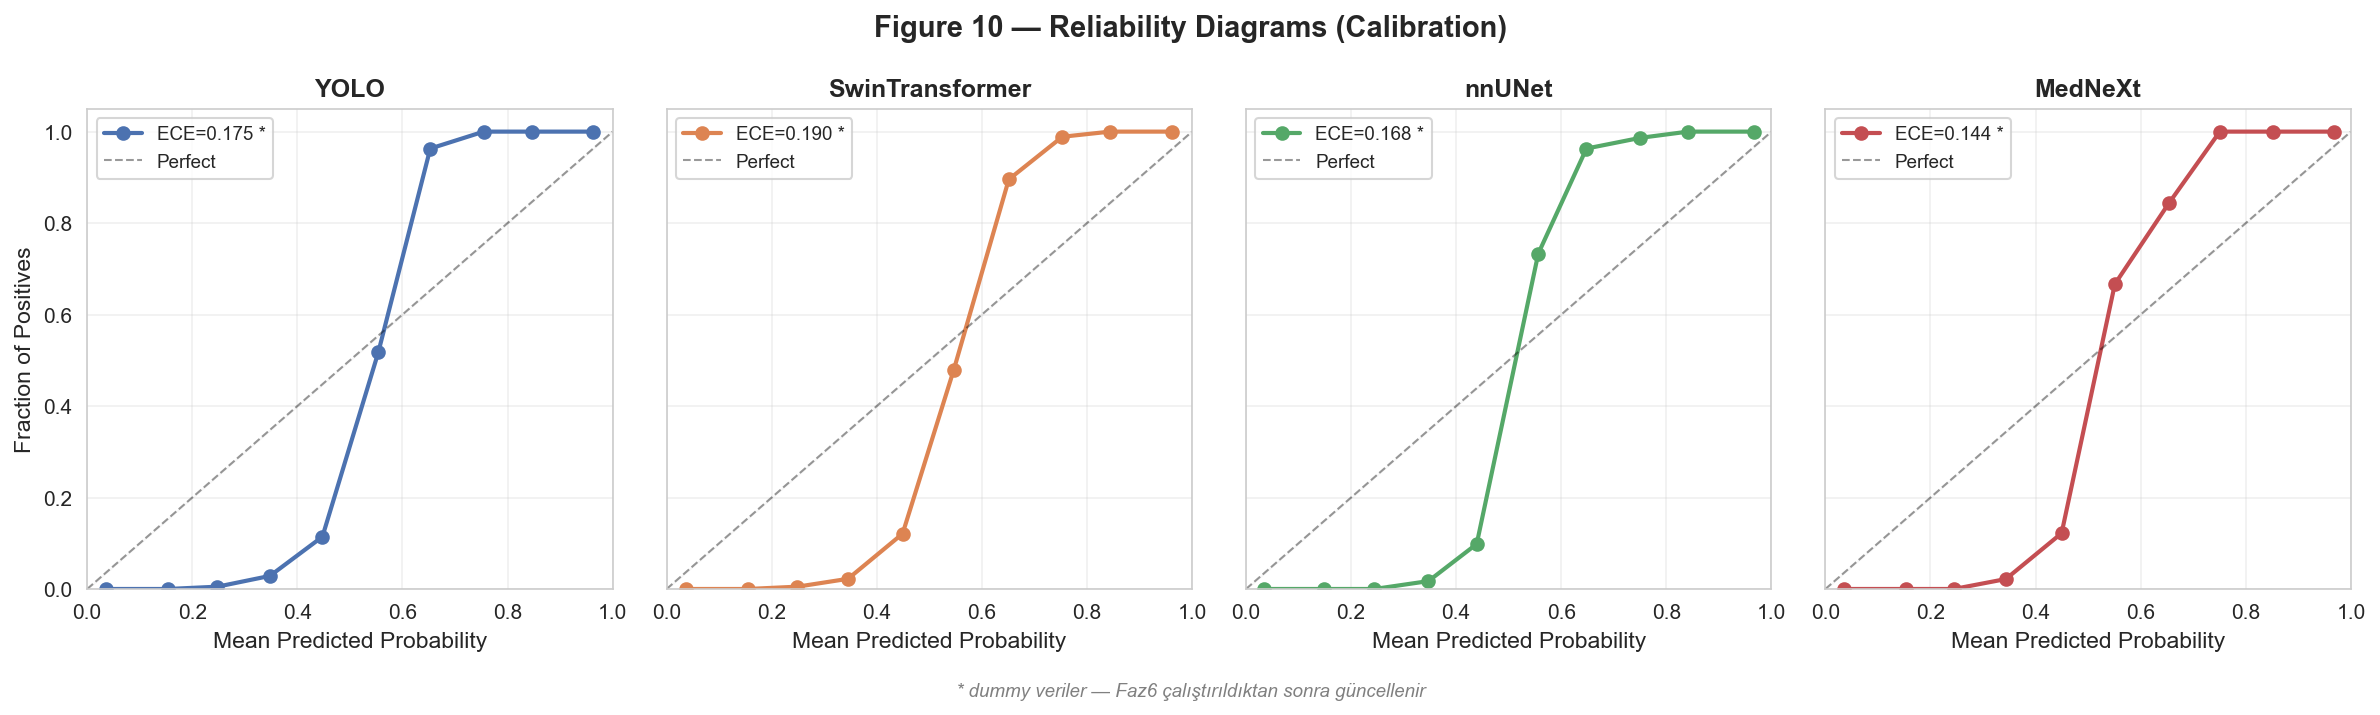

Fig10 kaydedildi.


In [48]:
from sklearn.calibration import calibration_curve

def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error (mikro ortalama, tüm sınıflar)."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    total = probs.size
    for b in range(n_bins):
        mask = (probs >= bins[b]) & (probs < bins[b+1])
        if mask.sum() == 0:
            continue
        acc  = labels[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / total) * abs(acc - conf)
    return ece

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4.5), sharey=True)
fig.suptitle('Figure 10 — Reliability Diagrams (Calibration)', fontsize=14, fontweight='bold')

for ax, model in zip(axes, MODELS):
    probs, labels, is_dummy = load_predictions(results, model)
    # mikro: tüm sınıfları düzleştir
    p_flat = probs.ravel()
    l_flat = labels.ravel()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        frac_pos, mean_pred = calibration_curve(l_flat, p_flat, n_bins=10, strategy='uniform')
    ece = compute_ece(p_flat, l_flat)
    lbl = f'ECE={ece:.3f}'
    if is_dummy: lbl += ' *'
    ax.plot(mean_pred, frac_pos, 'o-', color=MODEL_COLORS.get(model), linewidth=2, label=lbl)
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1, label='Perfect')
    ax.fill_between([0,1],[0,1],[0,1], alpha=0.06, color='gray')
    ax.set_xlabel('Mean Predicted Probability')
    if ax == axes[0]: ax.set_ylabel('Fraction of Positives')
    ax.set_title(model, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.grid(alpha=0.3)

fig.text(0.5, -0.03, '* dummy veriler — Faz6 çalıştırıldıktan sonra güncellenir',
         ha='center', fontsize=9, color='gray', style='italic')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig10_calibration.png')
fig.savefig(FIG_DIR / 'fig10_calibration.pdf')
plt.show()
print('Fig10 kaydedildi.')


## Fig 11 — 5-Fold Cross-Validation (Makale 2)

Faz7b_CrossVal_Cls.ipynb çalıştırıldıktan sonra `crossval_results.json` oluşur.

[UYARI] crossval_results.json bulunamadı → dummy veri kullanılıyor
[DUMMY DATA]
                         Fold 0  Fold 1  Fold 2  Fold 3  Fold 4    Mean     Std
Configuration                                                                  
Baseline (BCE)           0.5831  0.6212  0.6175  0.6389  0.6591  0.6240  0.0252
FocalBCE                 0.6165  0.6250  0.6179  0.6357  0.6550  0.6300  0.0142
FocalBCE+Sampler         0.6372  0.6521  0.6452  0.6426  0.6615  0.6477  0.0084
FocalBCE+Sampler+Thresh  0.6614  0.6435  0.6631  0.6922  0.6660  0.6652  0.0156


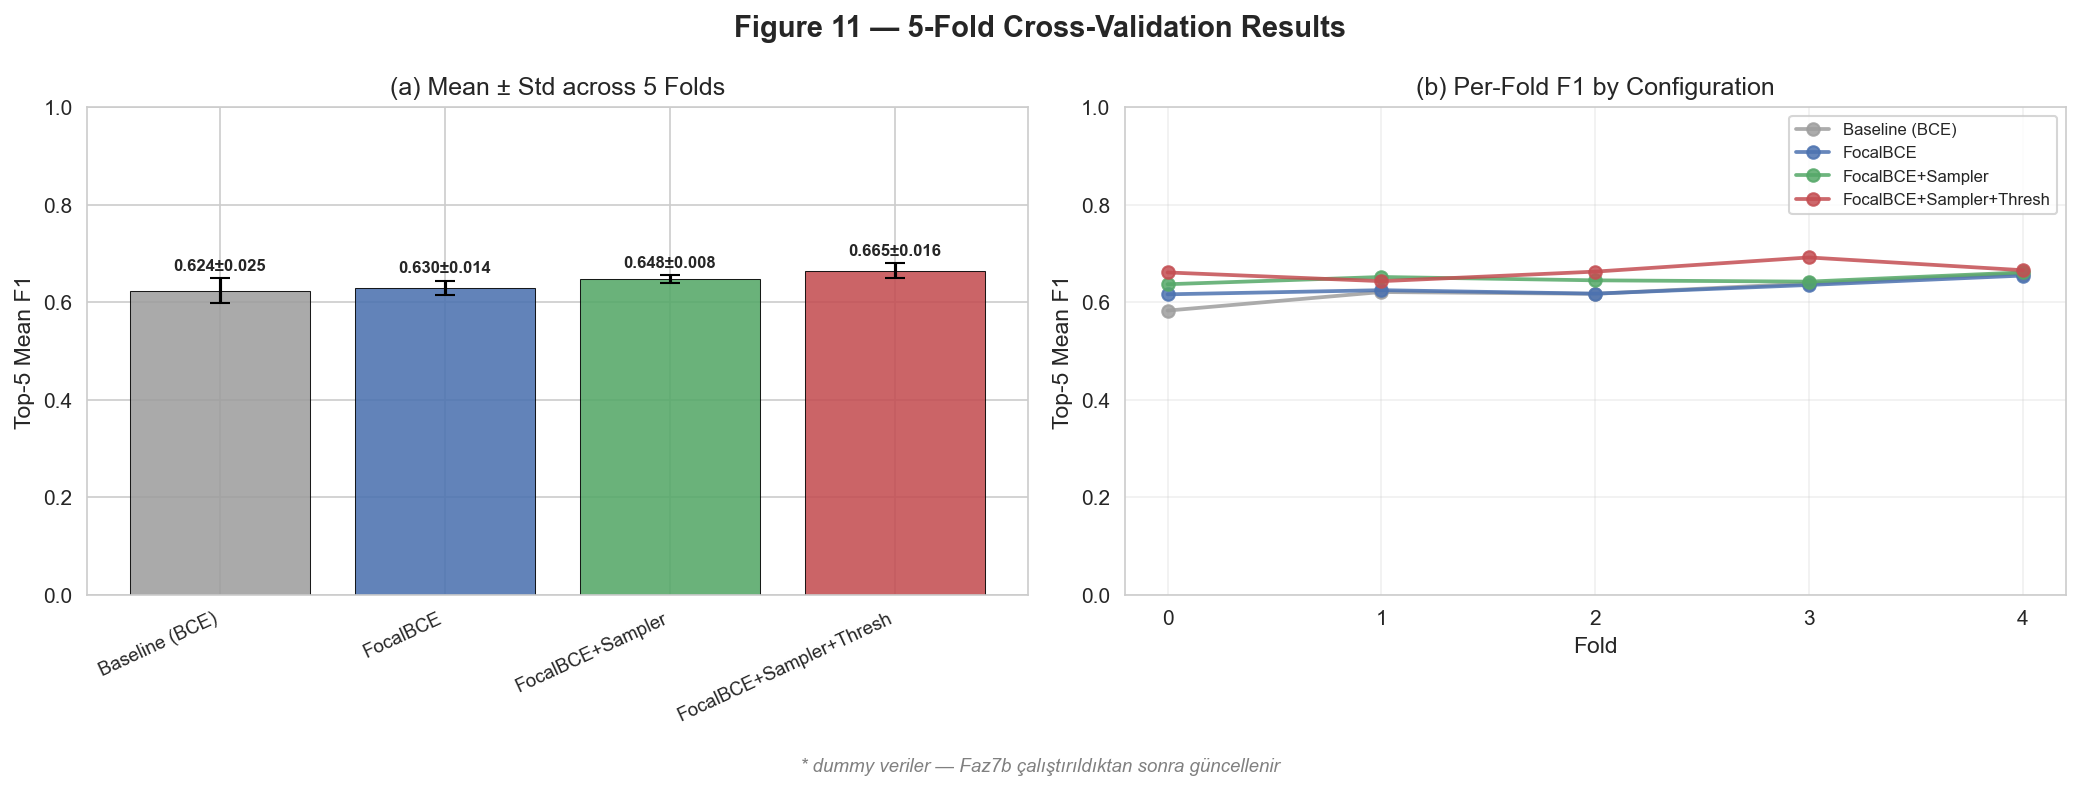

Fig11 kaydedildi.


In [49]:
cv_path = RESULTS_DIR / 'crossval_results.json'
cv_data = load_json(cv_path)
is_cv_dummy = cv_data is None

if is_cv_dummy:
    print('[UYARI] crossval_results.json bulunamadı → dummy veri kullanılıyor')
    rng = np.random.RandomState(7)
    configs = ['Baseline (BCE)', 'FocalBCE', 'FocalBCE+Sampler', 'FocalBCE+Sampler+Thresh']
    cv_data = {
        'configs': configs,
        'folds': list(range(5)),
        'per_fold_f1': {
            cfg: [round(0.60 + j*0.01 + k*0.015 + float(rng.uniform(-0.02,0.02)),4)
                  for k, cfg_ in enumerate(configs) for j in range(5)
                  if cfg_ == cfg]
            for cfg in configs
        }
    }

configs = cv_data['configs']
per_fold = cv_data['per_fold_f1']

means = {cfg: np.mean(per_fold[cfg]) for cfg in configs}
stds  = {cfg: np.std(per_fold[cfg])  for cfg in configs}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 11 — 5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

palette = ['#9E9E9E','#4C72B0','#55A868','#C44E52'][:len(configs)]

# Sol: mean ± std bar
x = np.arange(len(configs))
bars = axes[0].bar(x, [means[c] for c in configs],
                   yerr=[stds[c] for c in configs],
                   color=palette, edgecolor='black', linewidth=0.5,
                   alpha=0.88, capsize=5, error_kw={'elinewidth':1.5})
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs, rotation=25, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Top-5 Mean F1')
axes[0].set_title('(a) Mean ± Std across 5 Folds')
for bar, cfg in zip(bars, configs):
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h + stds[cfg] + 0.01,
                 f'{means[cfg]:.3f}±{stds[cfg]:.3f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Sağ: per-fold box/line plot
for i, cfg in enumerate(configs):
    folds = cv_data['folds']
    axes[1].plot(folds, per_fold[cfg], 'o-', color=palette[i], label=cfg,
                 linewidth=1.8, markersize=6, alpha=0.85)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Top-5 Mean F1')
axes[1].set_title('(b) Per-Fold F1 by Configuration')
axes[1].set_xticks(cv_data['folds'])
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# CV tablosu
cv_rows = []
for cfg in configs:
    row = {'Configuration': cfg}
    for fold, val in zip(cv_data['folds'], per_fold[cfg]):
        row[f'Fold {fold}'] = val
    row['Mean'] = round(means[cfg], 4)
    row['Std']  = round(stds[cfg], 4)
    cv_rows.append(row)
df_cv = pd.DataFrame(cv_rows).set_index('Configuration')
if is_cv_dummy:
    print('[DUMMY DATA]')
print(df_cv.to_string())
df_cv.to_csv(TABLE_DIR / 'table_crossval.csv')
df_cv.to_latex(TABLE_DIR / 'table_crossval.tex',
               float_format='%.4f',
               caption='5-fold cross-validation results: Top-5 Mean F1 per fold and overall mean±std.',
               label='tab:crossval')

if is_cv_dummy:
    fig.text(0.5, -0.03, '* dummy veriler — Faz7b çalıştırıldıktan sonra güncellenir',
             ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig11_crossval.png')
fig.savefig(FIG_DIR / 'fig11_crossval.pdf')
plt.show()
print('Fig11 kaydedildi.')


In [50]:
# Özet: tüm figür yollarını listele
print('=== Üretilen Figürler ===')
for p in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p}')

print('\n=== Üretilen Tablolar ===')
for p in sorted(TABLE_DIR.glob('*')):
    print(f'  {p}')

print(f'\nTüm çıktılar: {PAPER_DIR}')
print('Faz8 tamamlandı. Faz9_Word_Olustur.ipynb çalıştırarak Word dosyaları oluşturun.')
print('\n[NOT] Dummy (*) veriler Faz6 ve Faz7b çalıştırıldıktan sonra otomatik güncellenir.')

=== Üretilen Figürler ===
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig10_calibration.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig11_crossval.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig1_dataset_statistics.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig2_training_curves.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig3_model_comparison.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig4_per_class_f1_heatmap.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig5_backbone_ablation.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig6_error_analysis.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig7_ablation_sampler_threshold.png
  /Users/ramazanpolat/Desktop/datasets/abdomen/paper_output/figures/fig8_efficiency.png
  /Users/ramazanpolat/Desktop/dataset